In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

In [2]:
from diffusers import FluxPipeline
import torch

In [3]:
model_id = "black-forest-labs/FLUX.1-dev"
pipe = FluxPipeline.from_pretrained(model_id, torch_dtype=torch.bfloat16)
_ = pipe.to('cuda')

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


In [4]:
pipe.load_lora_weights('/amax/hchuz/ai-toolkit/output/texture_01/texture_01.safetensors')

In [13]:
pipe.unload_lora_weights()

In [5]:
kwargs = {
        'guidance_scale':2.5,
        'num_inference_steps':20,
    }

  0%|          | 0/20 [00:00<?, ?it/s]

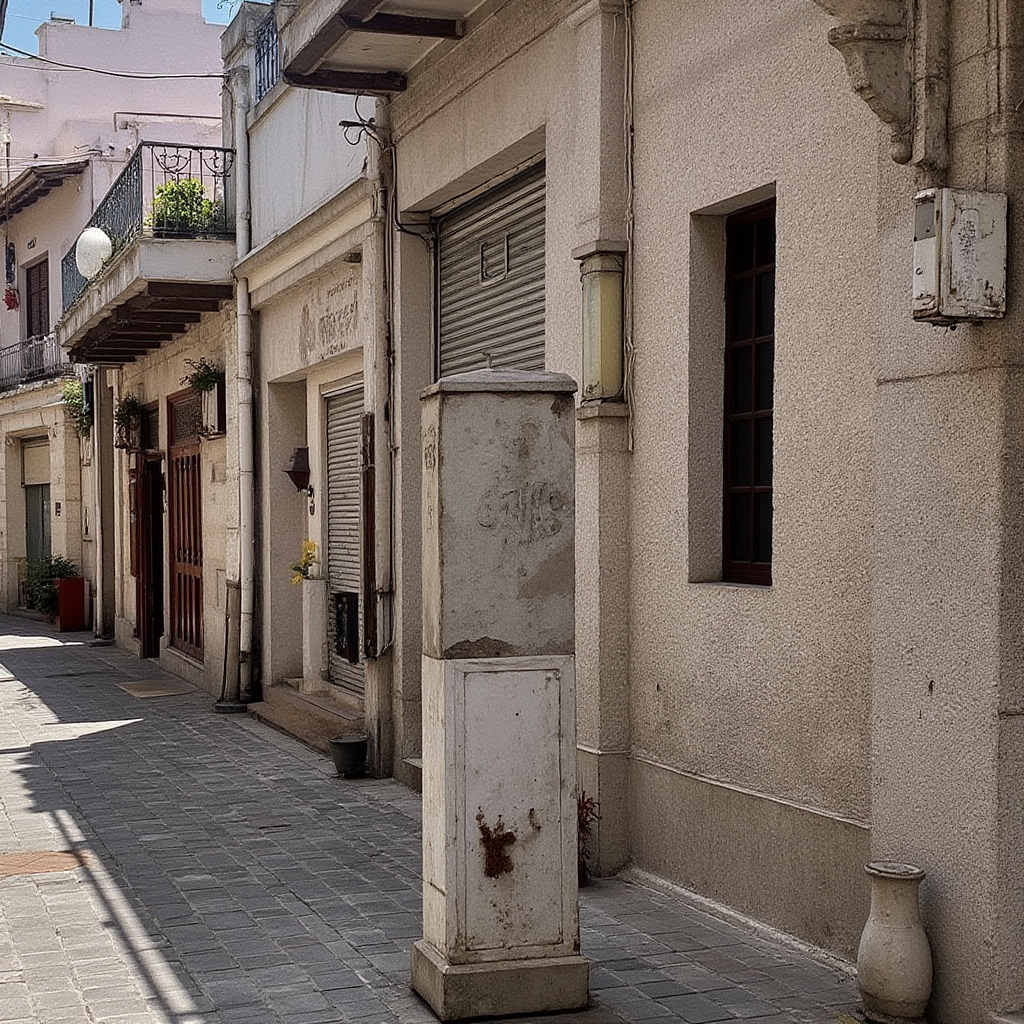

In [8]:
prompt = '[texture_01] an architectural heritage'
images = pipe(prompt, **kwargs)[0]
image = images[0]
image